# API Key 확인

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [3]:
#기존 캐시된 키 강제 제거
if 'OPENAI_API_KEY' in os.environ:
    del os.environ['OPENAI_API_KEY']

In [4]:
from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
#PINECONE_API_KEY = os.environ['PINECONE_API_KEY']

print("API 키 로드 완료")
print(f"OpenAI Key: {OPENAI_API_KEY[:10]}...")

API 키 로드 완료
OpenAI Key: sk-proj-00...


In [5]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [6]:
# Step 2 : LCEL 기본 체인 동작 확인
from dotenv import load_dotenv
load_dotenv()

True

prompt > LLM(ChatOpenAI) > output_parsers

In [7]:
text = "{topic}에 대한 한 문장으로 설명해줘"

In [8]:
llm = ChatOpenAI(model="gpt-4o-mini")
prompt = PromptTemplate.from_template(text)
output_parsers = StrOutputParser()

In [9]:
chain = prompt | llm | output_parsers

In [10]:
chain

PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='{topic}에 대한 한 문장으로 설명해줘')
| ChatOpenAI(profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x00000287201BE4B0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000287203FC200>, root_client=<openai.OpenAI object at 0x00000287201BE1E0>, root_async_clie

In [11]:
result = chain.invoke({"topic": "랭체인"})
result

'랭체인(LangChain)은 대규모 언어 모델을 활용하여 다양한 애플리케이션을 구축하고 연결하기 위한 프레임워크입니다.'

In [12]:
message = [
  ("system", "당신은 세계 최고의 펀드메니저입니다."),
  ("human", "2026년 대한민국에서 유망한 상장사 기업 5개 추천해주세요."),
]

In [13]:
res = llm.invoke(message)
res

AIMessage(content='2026년 대한민국의 상장사 중에서 유망할 것으로 예상되는 기업을 추천하기 위해서는 여러 요인을 고려해야 합니다. 산업 동향, 기술 혁신, 글로벌 경제 상황 등을 종합적으로 분석해야 하지만, 현재 시점에서 예상할 수 있는 기업 몇 가지를 소개해드리겠습니다. 다만, 이는 투자 조언이 아닌 참고용 정보라는 점을 유념해주시기 바랍니다.\n\n1. **삼성전자**: 반도체와 모바일 기기에서 세계적인 강자로, 5G와 인공지능(AI) 등 첨단 기술에 대한 투자 확대가 기대됩니다.\n\n2. **LG화학**: 전기차 배터리 및 신재생 에너지 관련 주목받는 기업으로, 지속 가능한 에너지 전환에 대한 수요 증가로 성장이 기대됩니다.\n\n3. **카카오**: 다양한 플랫폼을 통해 디지털 혁신을 이끌고 있으며, 결제 서비스와 콘텐츠, 광고 비즈니스에서 성장 가능성이 큽니다.\n\n4. **Naver**: 검색 포털 및 커머스, 광고 부문에서의 성장이 예상되며, AI와 데이터 사업도 다양한 기회를 제공할 것입니다.\n\n5. **셀트리온**: 바이오 의약품 제조사로, 글로벌 시장에서의 매출 증가가 기대되며, 신규 제품 개발과 해외 진출이 중요한 요소로 작용할 것입니다.\n\n이 기업들은 현재와 미래의 트렌드를 반영하여 성장이 기대되는 분야에 자리 잡고 있습니다. 하지만 실제 투자 결정을 내리기 전에 보다 심도 있는 분석과 여러 전문가의 조언을 참고하시기를 권장합니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 352, 'prompt_tokens': 42, 'total_tokens': 394, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_toke

# LangChain Agent 실습

In [14]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain.agents import create_agent   # LangChain 1.x
from langgraph.prebuilt import create_react_agent

In [15]:
@tool
def add(a:float, b:float) -> float:
    """두 숫자를 더합니다."""
    return a + b

In [16]:
@tool
def multiply(a:float, b:float) -> float:
    """두 숫자를 곱합니다."""
    return a * b

In [17]:
tools = [add, multiply] 

In [18]:
agent = create_react_agent(
  prompt = "당신은 계산을 도와주는 어시스턴트입니다.",
  model = llm,
  tools = tools
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6000\3823417671.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


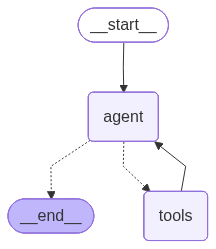

In [19]:
agent

In [20]:
result = agent.invoke({
  "messages": [{"role":"user", "content": "3 더하기 5는 얼마입니까? 그리고 다시 7을 곱하면 어떻게 될까요?"}]
})
result

{'messages': [HumanMessage(content='3 더하기 5는 얼마입니까? 그리고 다시 7을 곱하면 어떻게 될까요?', additional_kwargs={}, response_metadata={}, id='41501c10-efa2-4231-8bee-7d99b8a32364'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 107, 'total_tokens': 157, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a5086b7b9a', 'id': 'chatcmpl-DSCHxxc6NqJkGu8Sf42nfVtmK1hjJ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6ac5-04f8-7c73-a529-910384105413-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 5}, 'id': 'call_9dn3pBXhjKRaUYPHPwBR682g', 'type': 'tool_call'}, {'name': 'multiply', 'args': {'a': 8, 'b': 7}, 'id': 'call_95pCfC

In [21]:
for msg in result["messages"]:
    print(f"[{msg.__class__.__name__}] {msg.content[:80] if msg.content else '(tool call)'}")

[HumanMessage] 3 더하기 5는 얼마입니까? 그리고 다시 7을 곱하면 어떻게 될까요?
[AIMessage] (tool call)
[ToolMessage] 8.0
[ToolMessage] 56.0
[AIMessage] 3 더하기 5는 8입니다. 그리고 8에 7을 곱하면 56이 됩니다.


In [22]:
print(type(result))
print(result)


<class 'dict'>
{'messages': [HumanMessage(content='3 더하기 5는 얼마입니까? 그리고 다시 7을 곱하면 어떻게 될까요?', additional_kwargs={}, response_metadata={}, id='41501c10-efa2-4231-8bee-7d99b8a32364'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 107, 'total_tokens': 157, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a5086b7b9a', 'id': 'chatcmpl-DSCHxxc6NqJkGu8Sf42nfVtmK1hjJ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6ac5-04f8-7c73-a529-910384105413-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 5}, 'id': 'call_9dn3pBXhjKRaUYPHPwBR682g', 'type': 'tool_call'}, {'name': 'multiply', 'args': {'a': 8, 'b': 7}, 'id':

# 웹 검색 에이전트 도구 실습

In [23]:
from langchain_tavily import TavilySearch

In [24]:
search_tool = TavilySearch(max_results=3)

# import ast

In [25]:
import ast
import operator

# 2. 도구 정의: 안전한 계산기
SAFE_OPERATORS = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
}

def _safe_eval(node):
    if isinstance(node, ast.Constant):
        return node.value
    elif isinstance(node, ast.BinOp):
        op = SAFE_OPERATORS.get(type(node.op))
        if op is None:
            raise ValueError(f"지원하지 않는 연산자: {node.op}")
        return op(_safe_eval(node.left), _safe_eval(node.right))
    raise ValueError(f"허용되지 않는 표현식: {node}")

# safe calc 도구

In [26]:
@tool
def calculate(expression: str) -> str:
    """사칙연산과 거듭제곱만 허용하는 안전한 계산기입니다. 예: '1234 * 5678'"""
    try:
        tree = ast.parse(expression, mode="eval")
        result = _safe_eval(tree.body)
        return str(result)
    except Exception as e:
        return f"계산 오류: {e}"

# 에이전트 생성

In [27]:
# 3. 에이전트 생성
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [28]:
agent = create_react_agent(
    model=llm,
    tools=[search_tool, calculate],
    prompt="""당신은 웹 검색과 계산을 도와주는 AI 어시스턴트입니다.
    
규칙:
- 동일하거나 유사한 검색 쿼리를 반복하지 마세요.
- 검색 결과가 없으면 즉시 그 사실을 사용자에게 알리세요.
- 최대 3번 검색 후 반드시 최종 답변을 제공하세요.""",
)


C:\Users\Admin\AppData\Local\Temp\ipykernel_6000\3708413194.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


In [29]:
result = agent.invoke({
  "messages": [{"role":"user", 
                #"content": "3 더하기 5는 얼마입니까? 그리고 7을 곱하면 어떻게 될까요?"}]
                "content": "24년 한국의 GDP는 얼마입니까?"}]
})

In [30]:
result

{'messages': [HumanMessage(content='24년 한국의 GDP는 얼마입니까?', additional_kwargs={}, response_metadata={}, id='81bbd219-c618-48d7-965e-7499dbaa1870'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 1311, 'total_tokens': 1332, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a5086b7b9a', 'id': 'chatcmpl-DSCI0FMluxAo0qtrpkk7nqwUG8Dop', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6ac5-118f-7e53-af88-ce5239806711-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '2024 South Korea GDP forecast'}, 'id': 'call_670ySKt1BoEx44HZvvuWSG14', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input